In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from MATR_LFPGr_FastCharge_Data import Dataset_MATR_LFPGr

c:\Users\pgasper\AppData\Local\anaconda3\envs\cannele\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = Dataset_MATR_LFPGr(is_short=True) # Load only a subset of the cells for testing purposes

study_1_batch_1_cell_1
    Cycle 0: short time! max(time) = 0 mins
    Cycle 11: long time! max(time) = 642.7843449999999 mins
    Cycle 149: Qd[0] != 0! Qd[0] = 1.0740879
    Cycle 852: long time! max(time) = 317.43288500000006 mins
Skipping QV_dQdV for RPT start_time_s 32624.772999999997 because max(V) < 3.4 V
study_1_batch_1_cell_2
    Cycle 0: short time! max(time) = 0 mins
    Cycle 11: long time! max(time) = 460.98171166666674 mins
    Cycle 849: long time! max(time) = 317.0123050000004 mins
study_1_batch_2_cell_1
    Cycle 249: long time! max(time) = 545.4591449999997 mins
study_1_batch_2_cell_2
Skipping QV_dQdV for RPT start_time_s 439013.4641000001 because any(dQdV > 1 Ah) (spline fail)
study_1_batch_3_cell_1
study_1_batch_3_cell_2
    Cycle 583: long time! max(time) = 108.21207999999946 mins
study_2_batch_1_cell_1
study_2_batch_1_cell_2
study_2_batch_2_cell_1
study_2_batch_2_cell_2
study_2_batch_3_cell_1
study_2_batch_3_cell_2
study_2_batch_4_cell_1
study_2_batch_4_cell_2
stu

In [3]:
data.cell_extracts_and_metadata_to_df()

,cell_id,__class__,study,batch,policy_str,policy_rate_1,policy_rate_2,policy_rate_3,policy_rate_4,nominal_charging_time_minutes,MATR_cycle_life,cycle_life,log_cycle_life
0,study_1_batch_1_cell_1,CellData_MATR_LFPGr,study_1,batch_1,3.6C(80%)-3.6C,3.6,3.6,3.60,3.600,13.333333,1190.0,1190.0,7.081709
1,study_1_batch_1_cell_2,CellData_MATR_LFPGr,study_1,batch_1,3.6C(80%)-3.6C,3.6,3.6,3.60,3.600,13.333333,1179.0,1179.0,7.072422
2,study_1_batch_2_cell_1,CellData_MATR_LFPGr,study_1,batch_2,1C(4%)-6C,5.0,6.0,6.00,6.000,8.120000,300.0,300.0,5.703782
3,study_1_batch_2_cell_2,CellData_MATR_LFPGr,study_1,batch_2,2C(10%)-6C,4.0,6.0,6.00,6.000,8.300000,148.0,148.0,4.997212
4,study_1_batch_3_cell_1,CellData_MATR_LFPGr,study_1,batch_3,5C(67%)-4C-newstructure,5.0,5.0,5.00,4.350,9.600000,1009.0,1009.0,6.916715
5,study_1_batch_3_cell_2,CellData_MATR_LFPGr,study_1,batch_3,5.3C(54%)-4C-newstructure,5.3,5.3,4.91,4.000,9.728310,1063.0,1063.0,6.968850
6,study_2_batch_1_cell_1,CellData_MATR_LFPGr,study_2,batch_1,4-6-5.6-4.2,4.0,6.0,5.60,4.200,10.000000,NaN,NaN,NaN
7,study_2_batch_1_cell_2,CellData_MATR_LFPGr,study_2,batch_1,6-4-5.2-4.457,6.0,4.0,5.20,4.457,10.000086,NaN,NaN,NaN
8,study_2_batch_2_cell_1,CellData_MATR_LFPGr,study_2,batch_2,4.4-6-4.8-4.328,4.4,6.0,4.80,4.328,9.999916,NaN,NaN,NaN
9,study_2_batch_2_cell_2,CellData_MATR_LFPGr,study_2,batch_2,4.8-6-5.6-3.574,4.8,6.0,5.60,3.574,10.000440,NaN,NaN,NaN


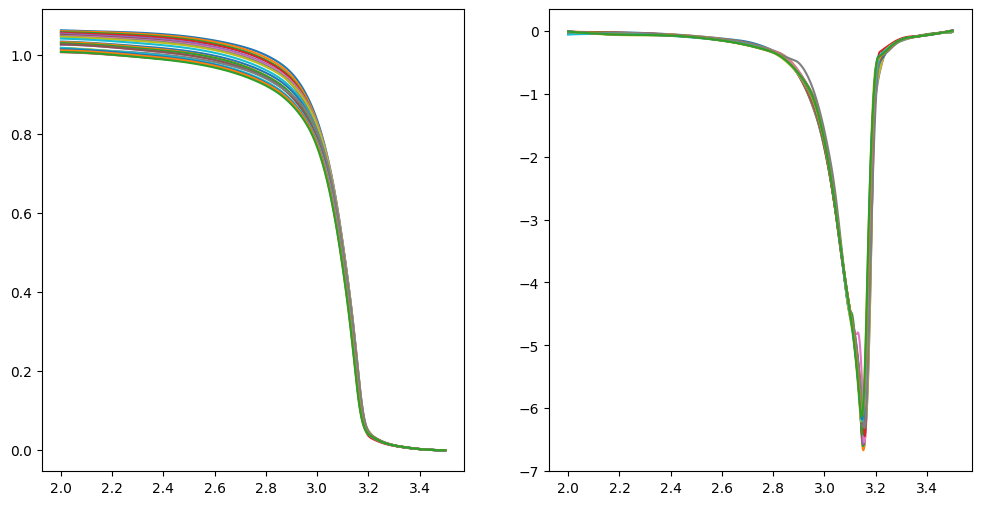

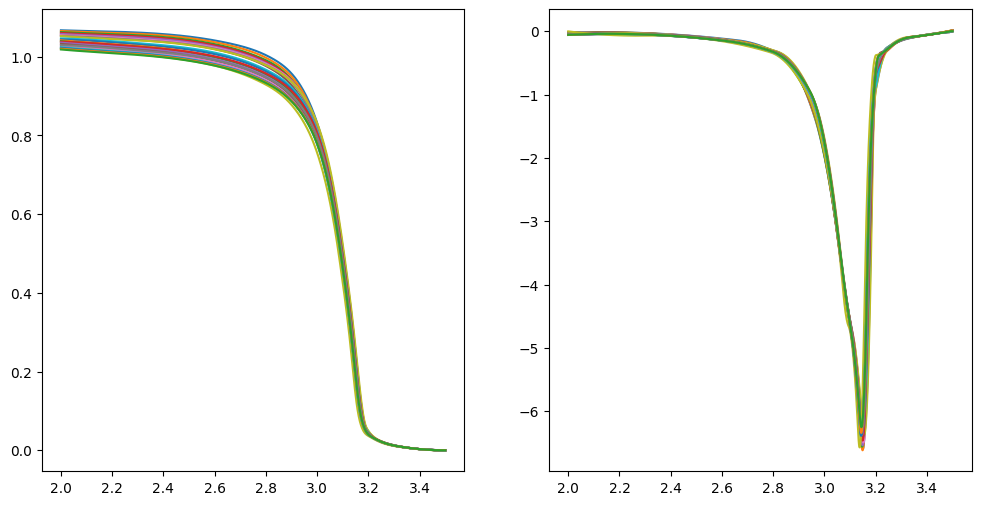

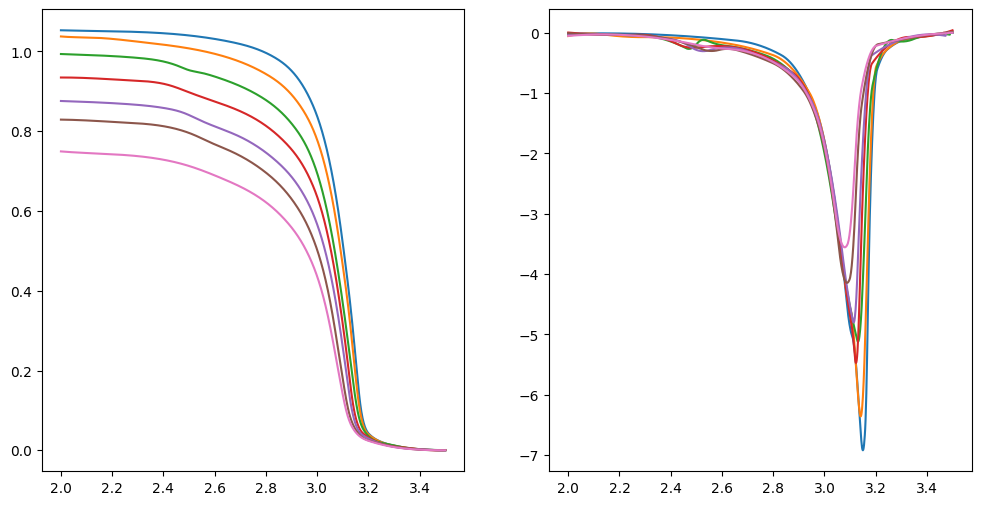

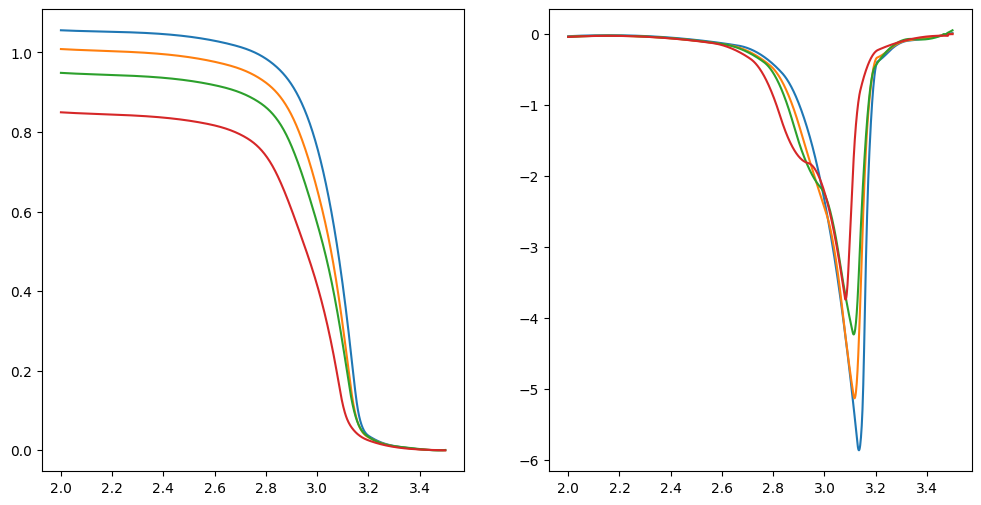

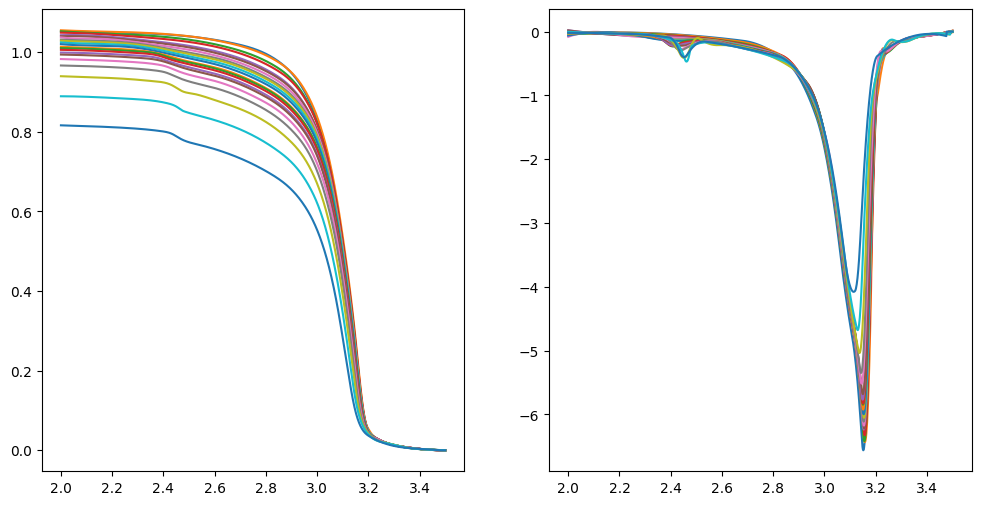

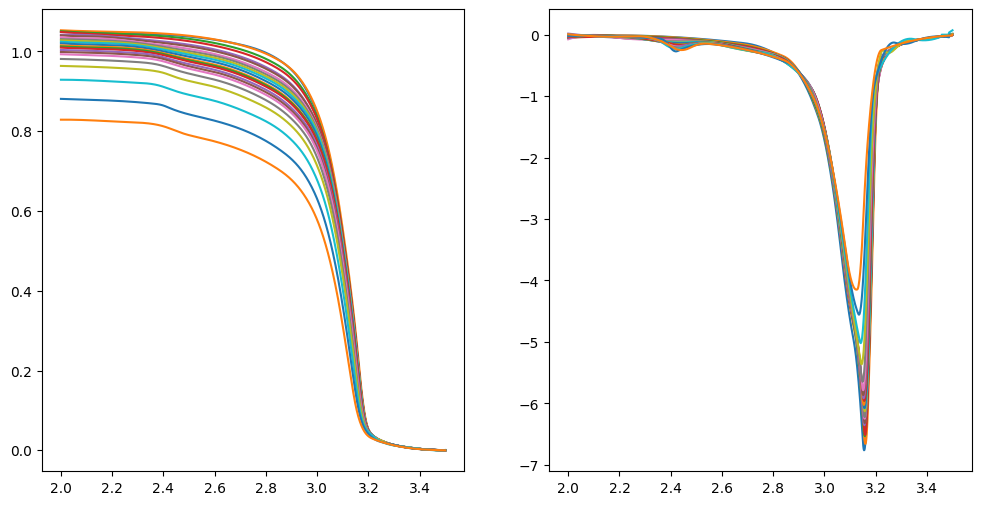

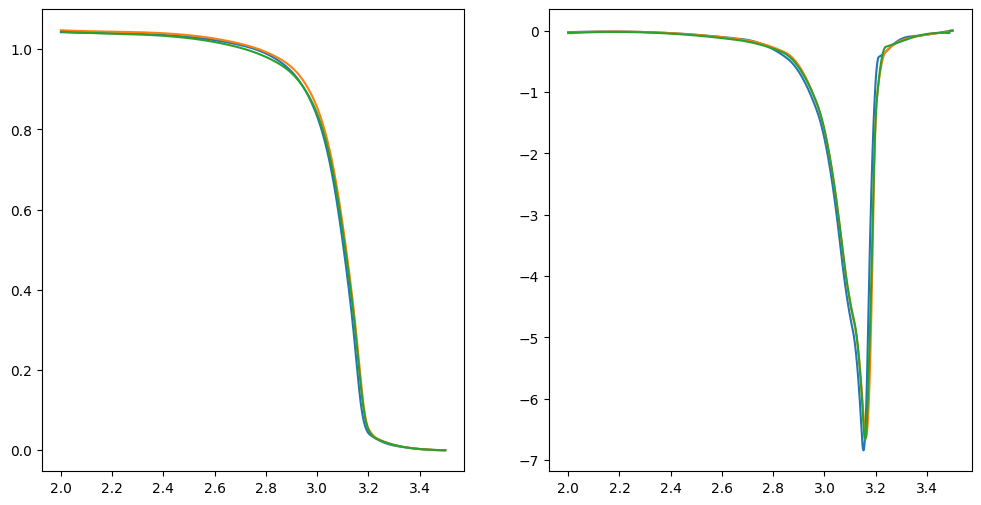

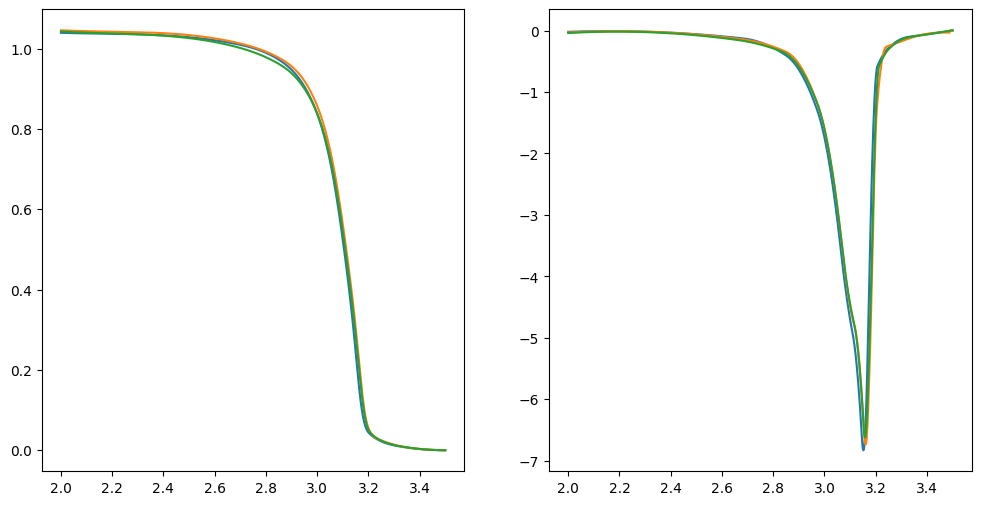

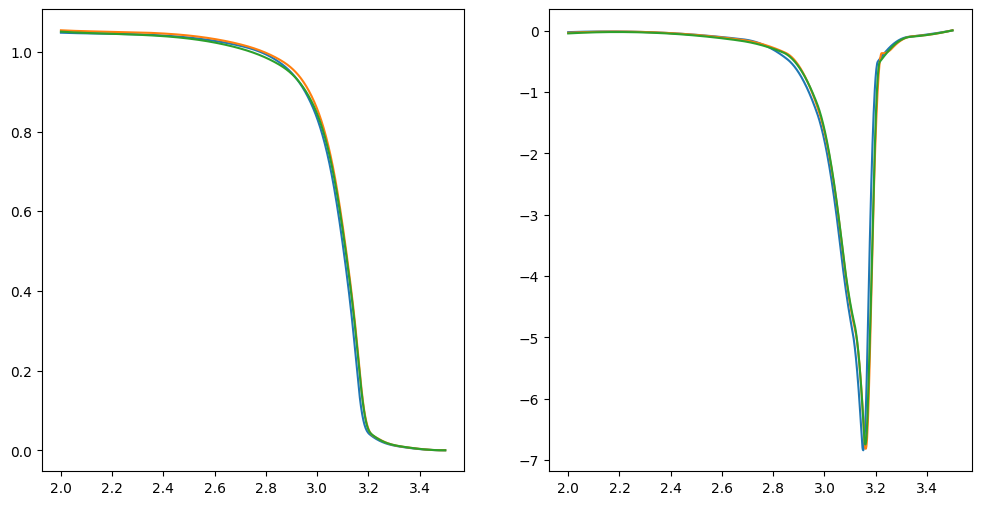

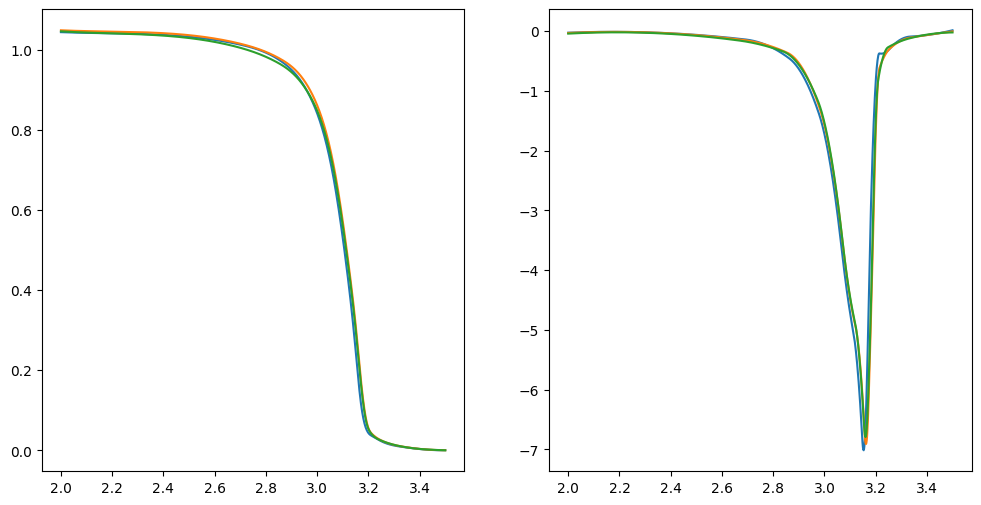

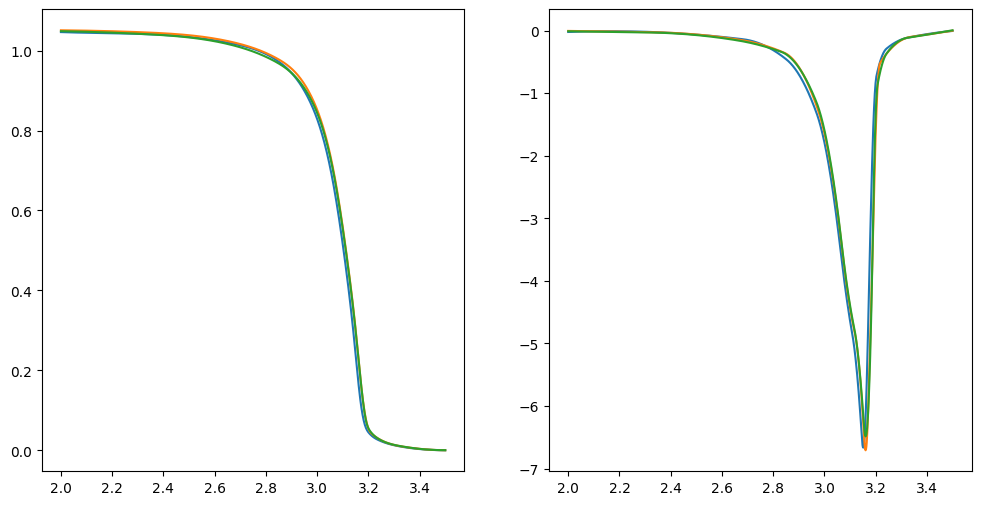

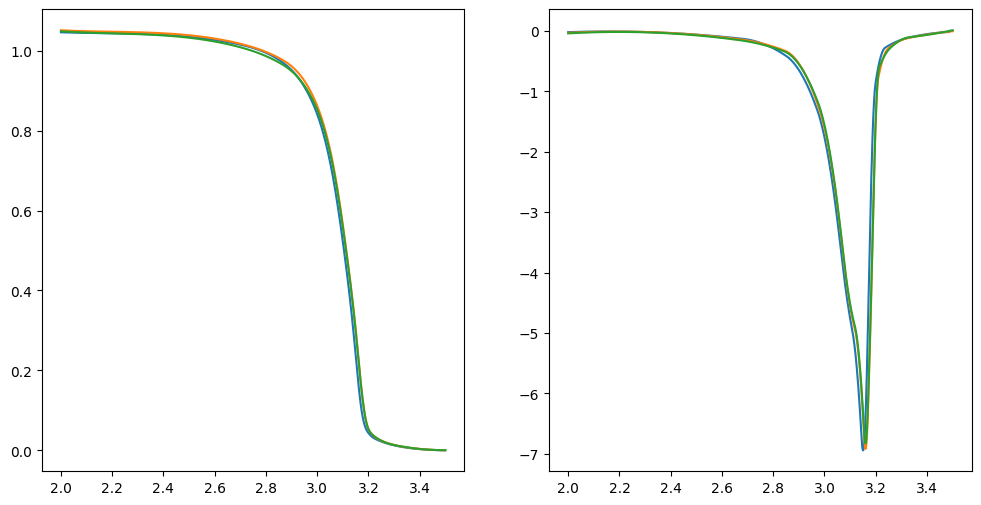

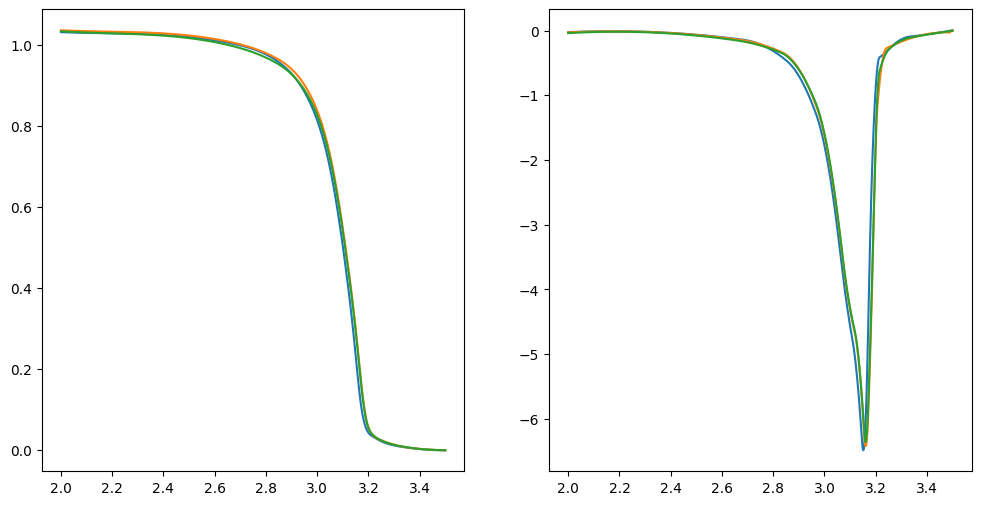

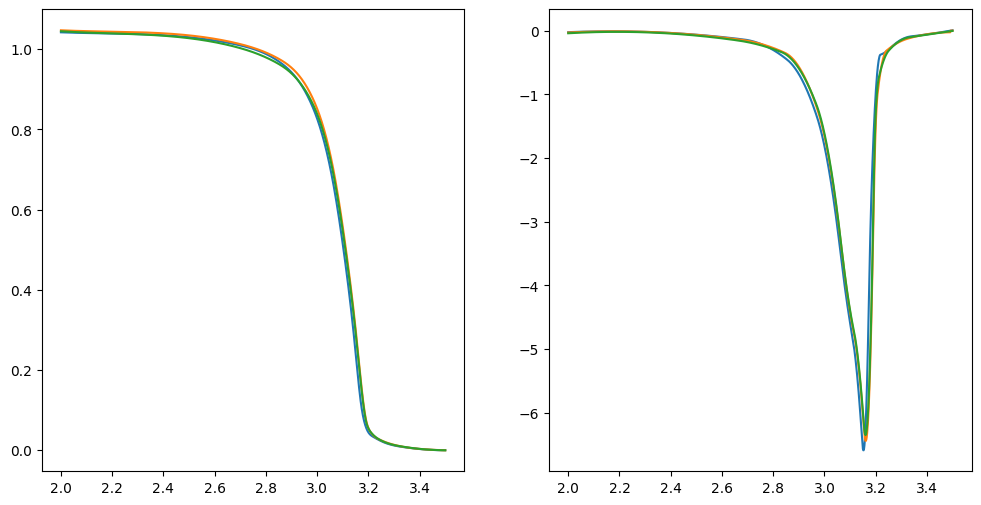

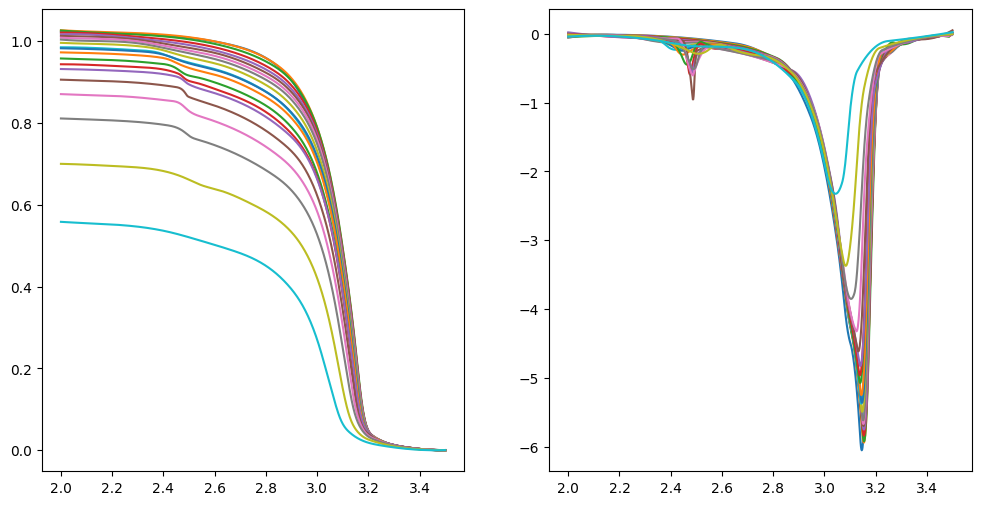

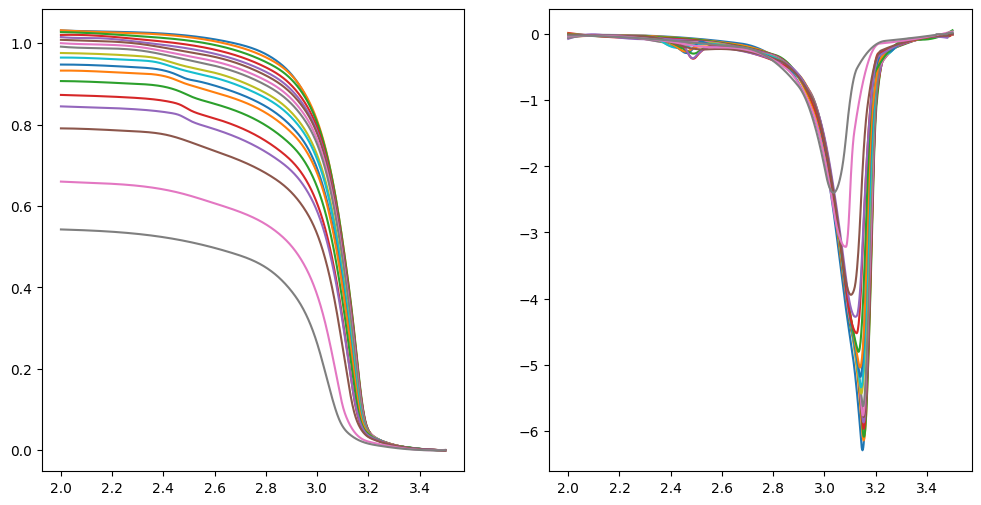

In [9]:
for cell in data:
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    for discharge in cell.measurement_extracts['discharge_QV_dQdV_dVdQ'][::50]:
        if discharge is None:
            continue
        ax[0].plot(discharge['Voltage_V'], discharge['Capacity_Ah'])
        ax[1].plot(discharge['Voltage_V'], discharge['dQdV_Ah/V'])

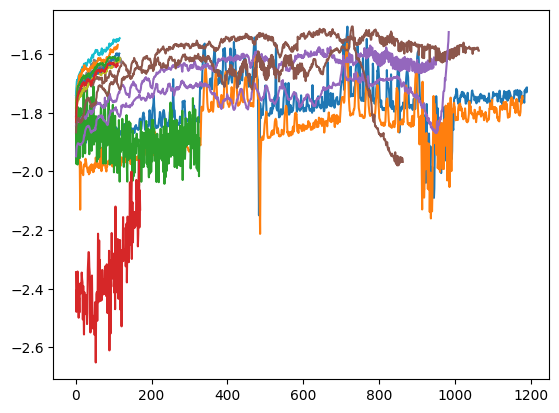

In [5]:
for cell in data:
    plt.plot(cell.cycle, cell.measurement_extracts['discharge_dQdV_3000mV'])

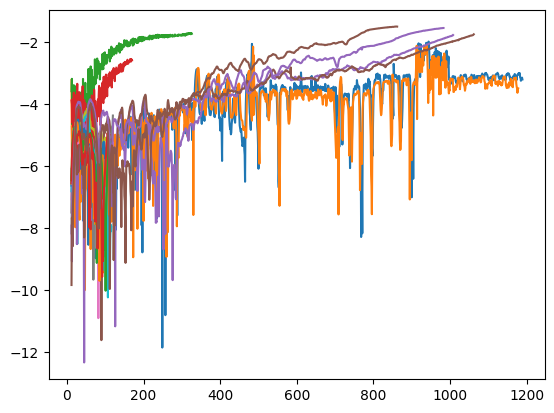

In [6]:
for cell in data:
    plt.plot(cell.cycle, cell.measurement_extracts['discharge_log_abs_delta_QV_3150mV'])

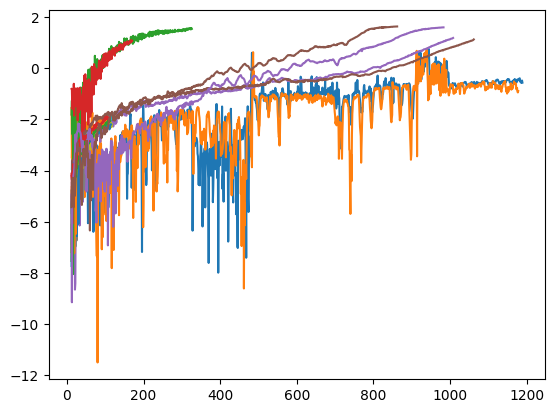

In [7]:
for cell in data:
    plt.plot(cell.cycle, cell.measurement_extracts['discharge_log_abs_delta_dQdV_3150mV'])